In [1]:
from data.dataset import MNISTAdditionDataset
import matplotlib.pyplot as plt
from utils.config import load_config
import torch
from torchvision import transforms
from pathlib import Path
import numpy as np

Note that in the following version, we have turned on the visualization tool in the dataset script.

In [2]:
PROJECT_ROOT = Path.cwd().parent  # Adjust if needed based on notebook location
config = load_config('config.toml')

transform = transforms.Compose([
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST normalization
])


Initializing training dataset...
Loading MNIST dataset...
Training set downloaded successfully
Test set downloaded successfully
Loading training split...
Successfully loaded 60000 samples
Creating digit indices mapping...
Found 5923 samples for digit 0
Found 6742 samples for digit 1
Found 5958 samples for digit 2
Found 6131 samples for digit 3
Found 5842 samples for digit 4
Found 5421 samples for digit 5
Found 5918 samples for digit 6
Found 6265 samples for digit 7
Found 5851 samples for digit 8
Found 5949 samples for digit 9
Generating pairs...
Expected dataset size: 19000 pairs
Actually generated 19000 pairs
Generated 19000 pairs


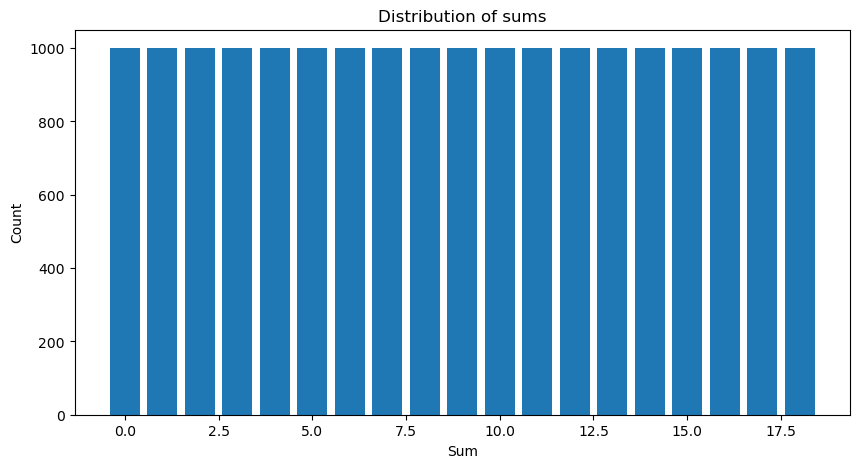

Dataset initialization complete


In [3]:
dataset = MNISTAdditionDataset(
    root="mnist_addition/data",
    train=True,
    transform=None,  # No normalization for visualization
    seed=43
)


In [4]:
def visualize_samples(dataset, num_samples=20):
    grid_size = int(np.ceil(np.sqrt(num_samples)))
    plt.figure(figsize=(20, 20))
    for i in range(num_samples):
        img, target = dataset[i]
        
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(img.squeeze(), cmap='gray')
        plt.title(f'Sum = {target}')
        plt.axis('off')
    
    plt.suptitle('Sample Image Pairs with Their Sums', size=16)
    plt.tight_layout()
    plt.show()

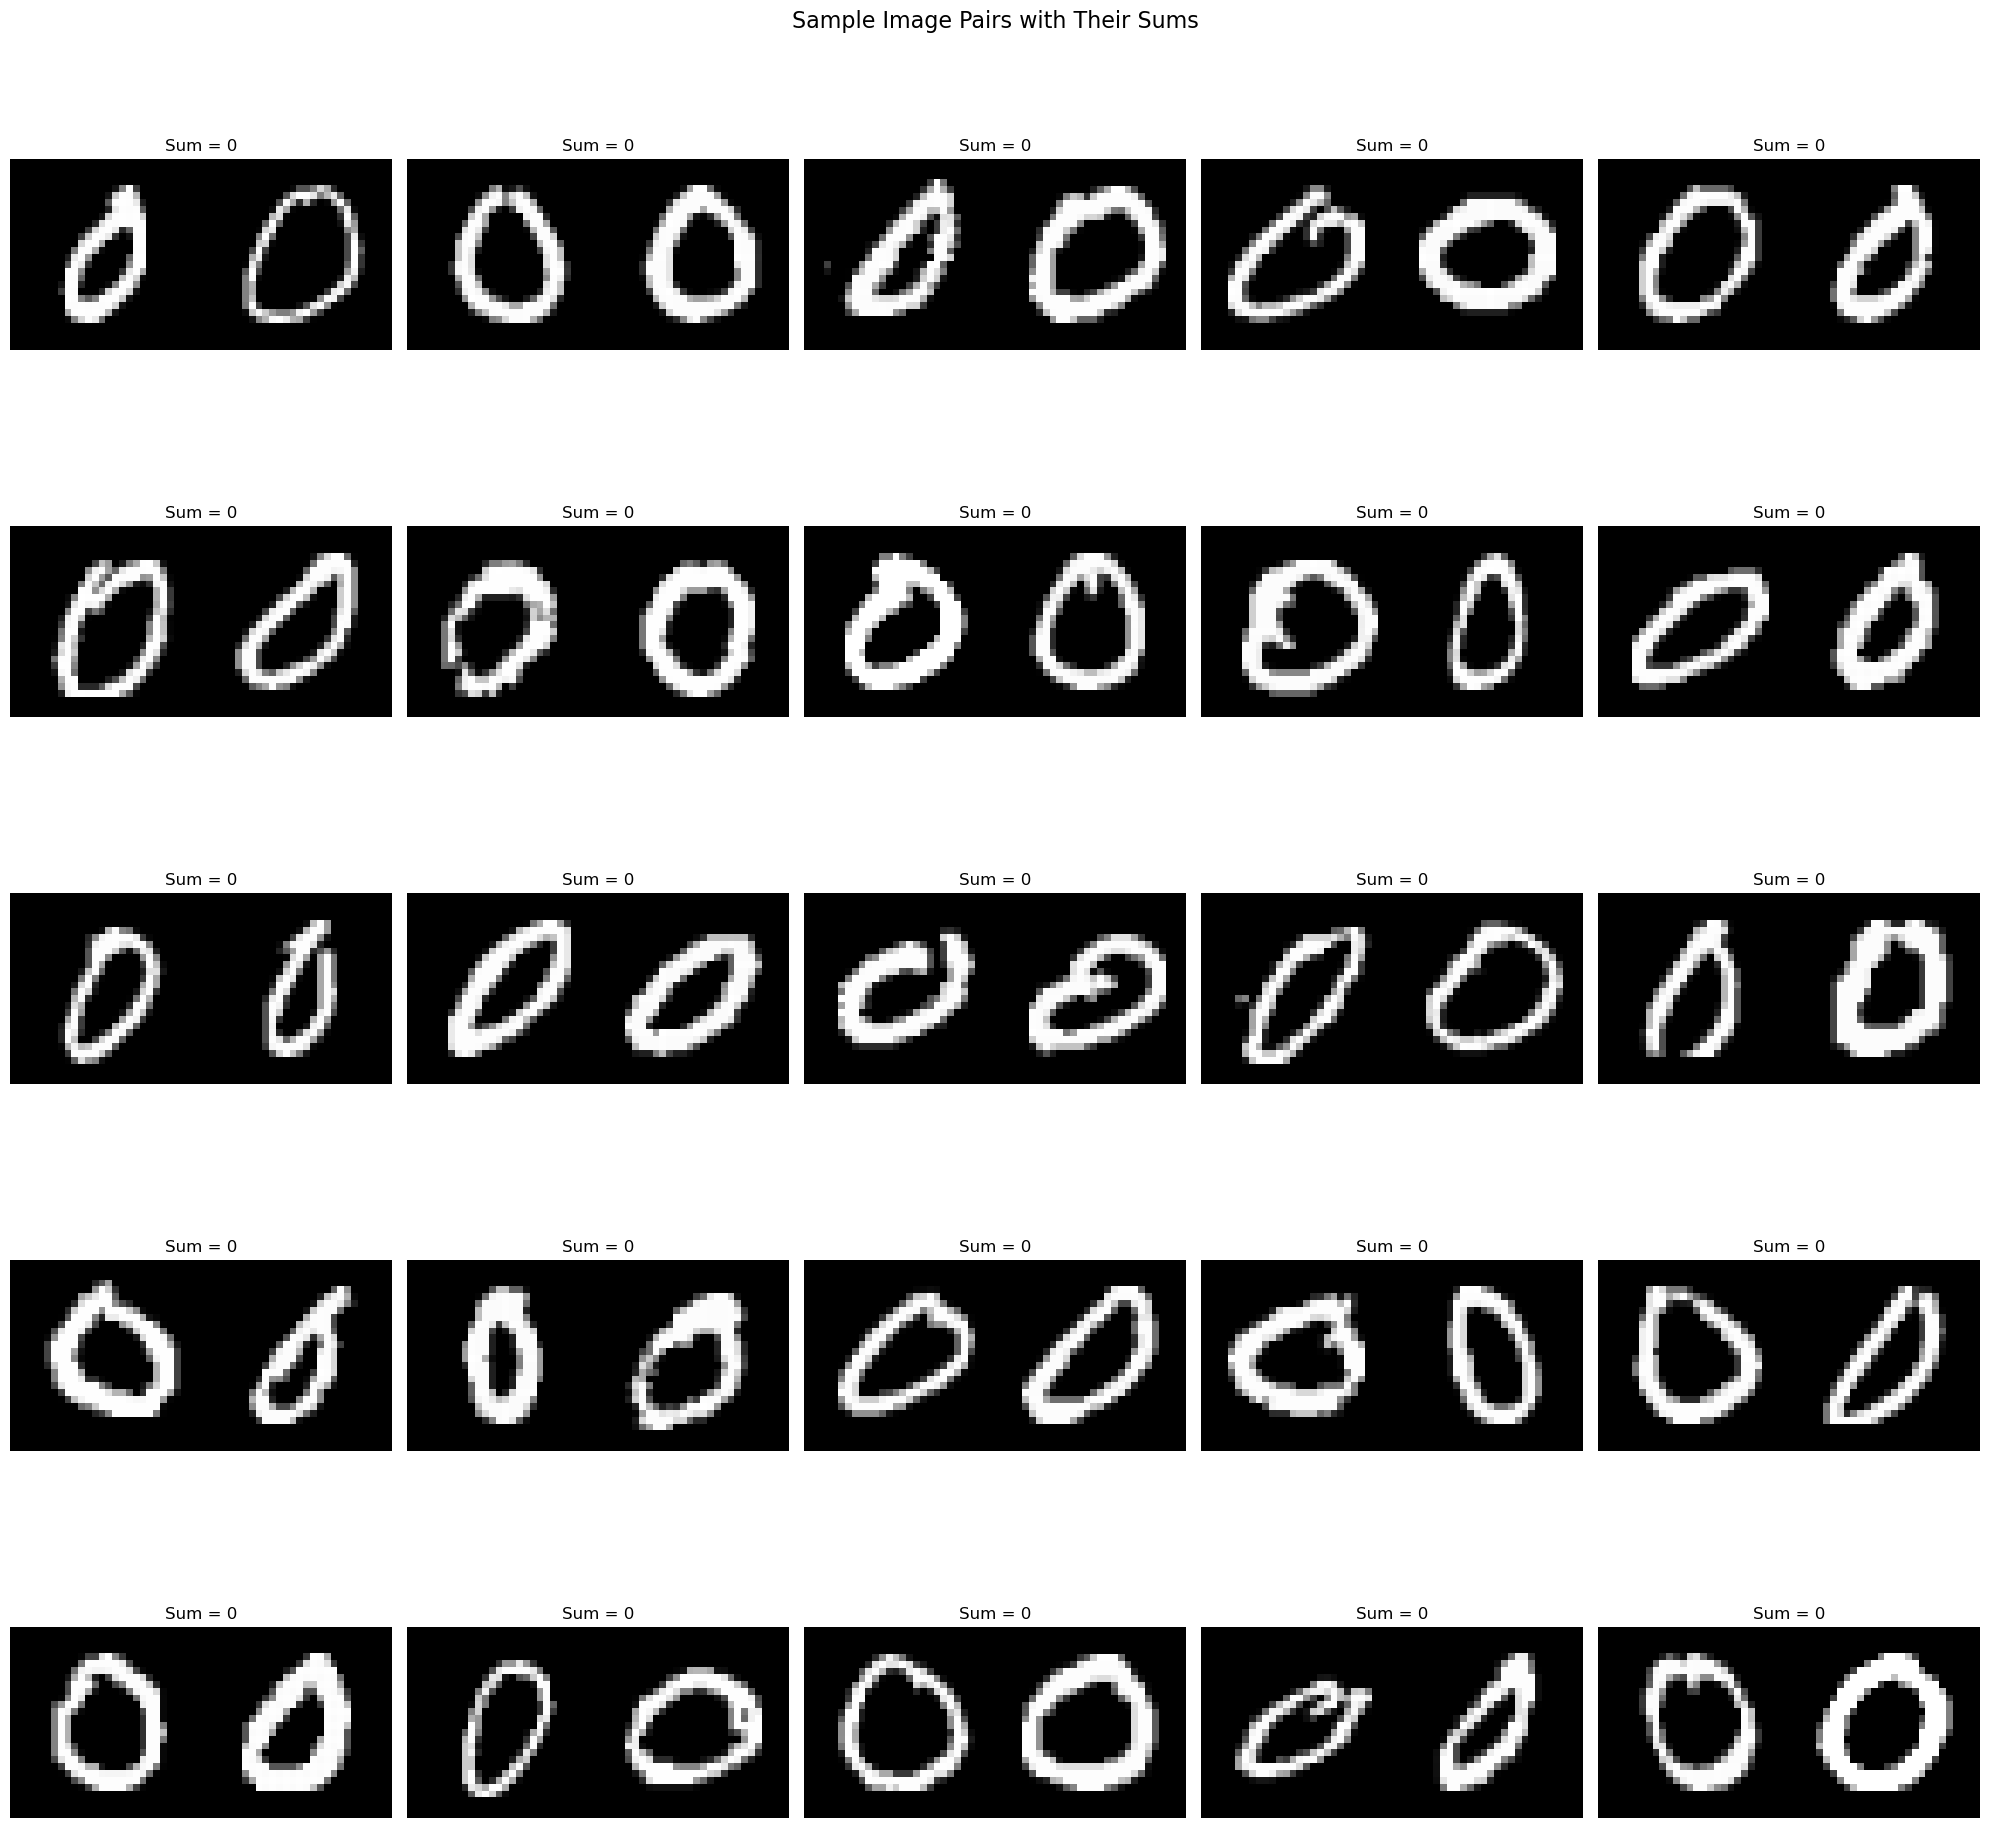

In [5]:
# Run visualization
visualize_samples(dataset, num_samples=25)

In [6]:
print(f"\nDataset Statistics:")
print(f"Total samples: {len(dataset)}")
print(f"Image shape: {dataset[0][0].shape}")


Dataset Statistics:
Total samples: 19000
Image shape: torch.Size([1, 28, 56])


In [7]:
def view_sample(idx):
    """View any sample by index"""
    img, target = dataset[idx]
    
    # Split the concatenated image
    img1 = img[:, :, :28]  # First digit
    img2 = img[:, :, 28:]  # Second digit
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img1.squeeze(), cmap='gray')
    plt.title('First Digit')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(img2.squeeze(), cmap='gray')
    plt.title('Second Digit')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f'Combined (Sum = {target})')
    plt.axis('off')
    
    plt.suptitle(f'Sample {idx} Breakdown')
    plt.show()

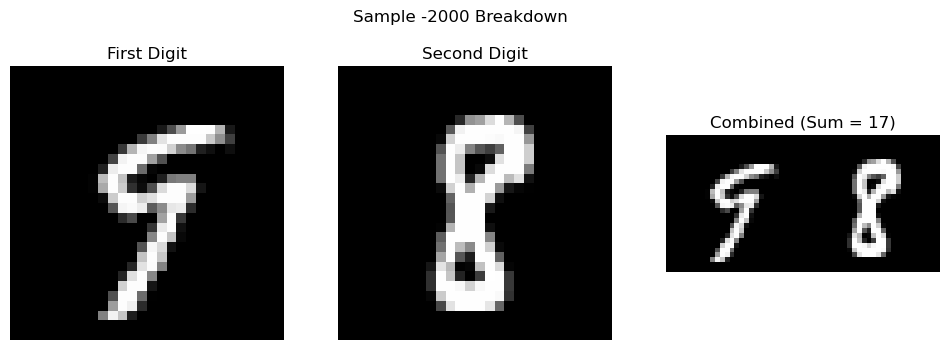

In [8]:
#to view individual samples
view_sample(-2000) 

In [9]:
def compare_sums(dataset, sums_to_show=range(5), samples_per_sum=5):
    num_sums = len(sums_to_show)
    plt.figure(figsize=(20, 4 * num_sums))
    
    for row, target_sum in enumerate(sums_to_show):
        indices = [i for i, (_, sum_) in enumerate(dataset) if sum_ == target_sum]
        
        for col in range(samples_per_sum):
            if indices:
                img, _ = dataset[np.random.choice(indices)]
                plt.subplot(num_sums, samples_per_sum, row * samples_per_sum + col + 1)
                plt.imshow(img.squeeze(), cmap='gray')
                plt.title(f'Sum = {target_sum}')
                plt.axis('off')
    
    plt.suptitle('Comparison of Different Sums', size=16)
    plt.tight_layout()
    plt.show()


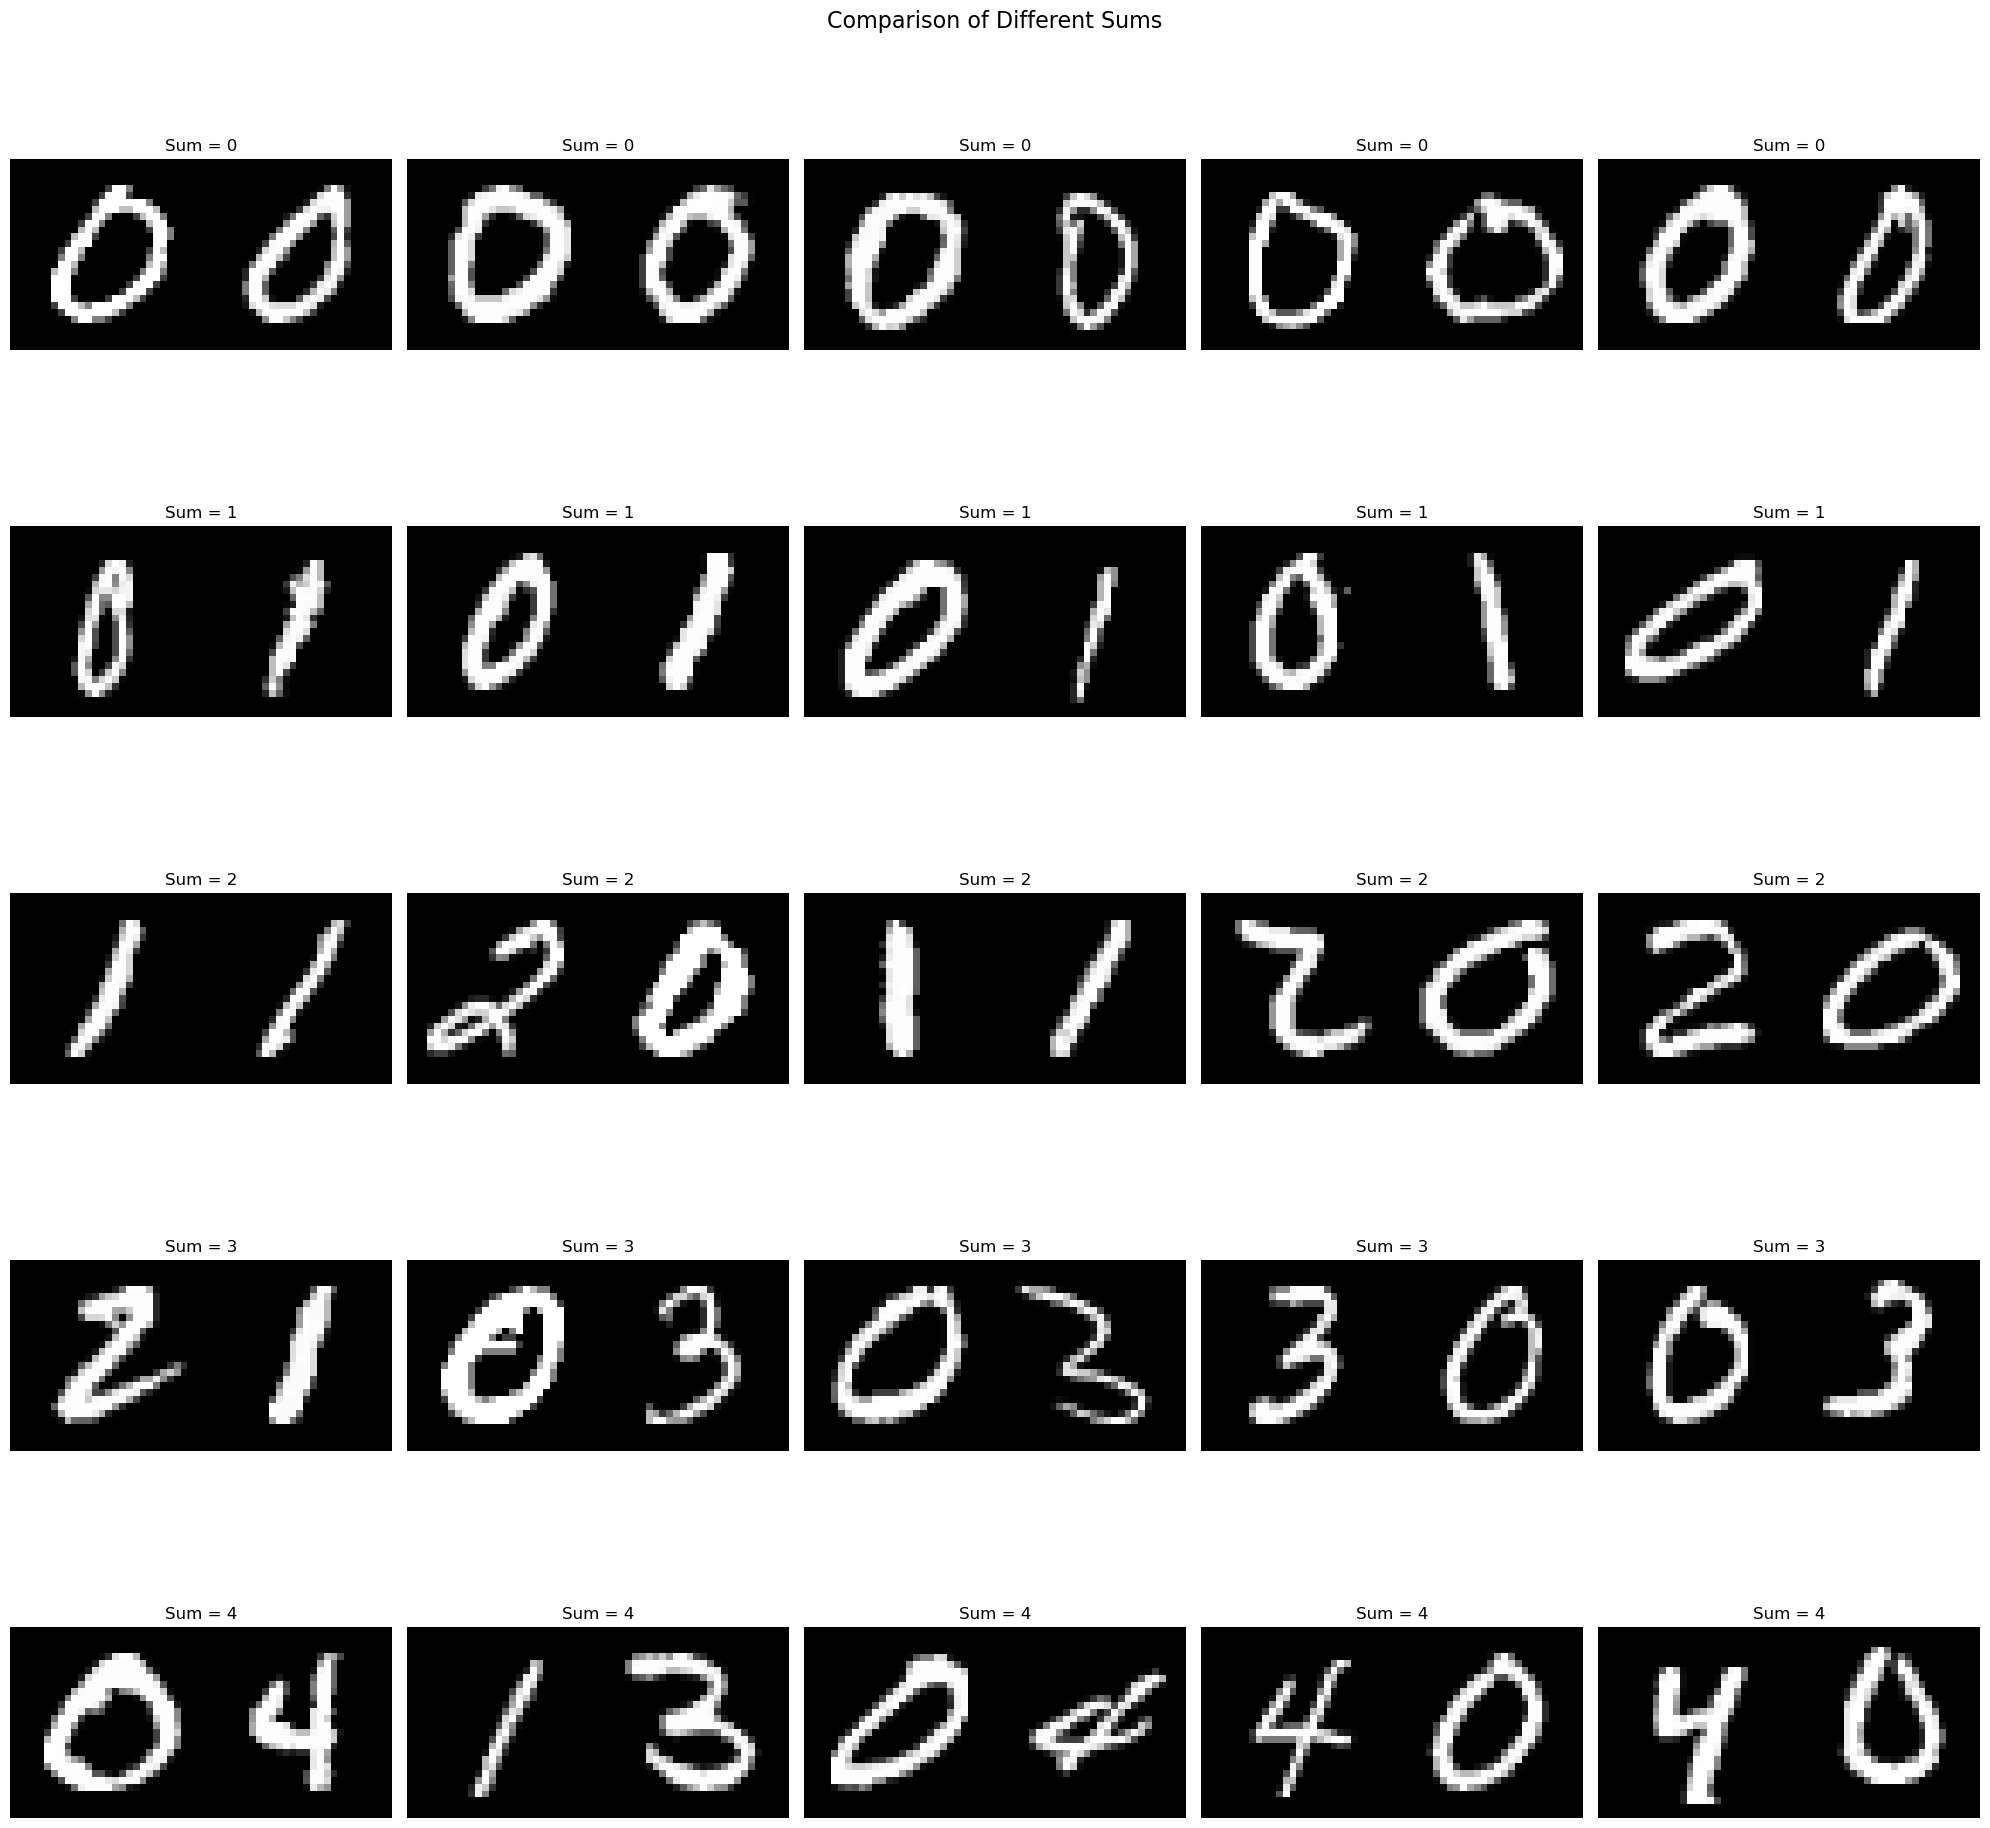

In [10]:
# Compare samples for sums 0-4, showing 5 examples each
compare_sums(dataset, sums_to_show=range(5), samples_per_sum=5)


Initializing training dataset...
Loading MNIST dataset...
Training set downloaded successfully
Test set downloaded successfully
Loading training split...
Successfully loaded 60000 samples
Creating digit indices mapping...
Found 5923 samples for digit 0
Found 6742 samples for digit 1
Found 5958 samples for digit 2
Found 6131 samples for digit 3
Found 5842 samples for digit 4
Found 5421 samples for digit 5
Found 5918 samples for digit 6
Found 6265 samples for digit 7
Found 5851 samples for digit 8
Found 5949 samples for digit 9
Generating pairs...
Generating 19000 random pairs...
Actually generated 19000 pairs
Generated 19000 pairs


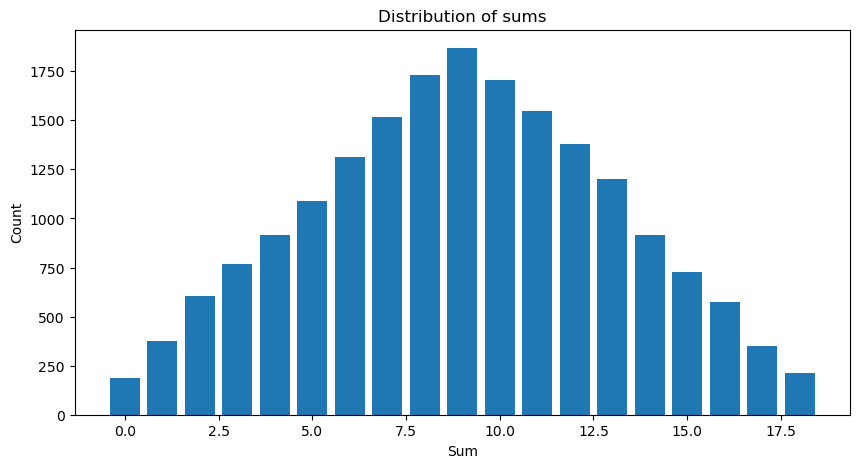

Dataset initialization complete


In [11]:
dataset = MNISTAdditionDataset(
    root="mnist_addition/data",
    train=True,
    transform=None,  # No normalization for visualization
    seed=43,
    balanced=False #later on we will test which oe works better
)